# Importing

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
# Ridge
from sklearn.linear_model import Ridge
#Lasso
from sklearn.linear_model import Lasso

# Reading dataset

* Link: https://www.kaggle.com/datasets/yasserh/housing-prices-dataset?resource=download
* The dataset consists of 12 columns with 545 rows
* Columns names are: price (Price of the Houses), area (Area of a House), bedrooms (Number of House Bedrooms), bathrooms (Number if Bathrooms), stories (Number of House Stories), mainroad (Weather connected to Main Road), guestroom (Weather has a guest room), basement(Weather has a basement), hotwaterheating (Weather has a hotwater heater), airconditioning (Weather has an airconditioning), parking(Number of parking space aviable in the house), prefarea (Whether the house is located in preferred area or not), furnishingstatus (Finishing condition of house)

In [5]:
df = pd.read_csv('/content/Housing.csv')
df.head()

,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


preprocessing

In [6]:
df["mainroad"] = (df["mainroad"] == "yes").astype(int) # If connected with main road mark it 1 else 0
df["guestroom"] = (df["guestroom"] == "yes").astype(int) # If have guestroom then mark it with 1 else 0
df["basement"] = (df["basement"] == "yes").astype(int) # If have basement then mark it with 1 else 0
df["hotwaterheating"] = (df["hotwaterheating"] == "yes").astype(int)# If have hotwaterheating then mark it with 1 else 0
df["airconditioning"] = (df["airconditioning"] == "yes").astype(int)# If have airconditioning then mark it with 1 else 0
df["prefarea"] = (df["prefarea"] == "yes").astype(int)# If it is a prefarea then mark it with 1 else 0
# since we have to do binary classification so semi-furnished, will be replaced with unfurnished
df["furnishingstatus"].replace("semi-furnished", "unfurnished", inplace=True)
df["furnishingstatus"] = (df["furnishingstatus"] == "furnished").astype(int)# If furnishingstatus is finished then mark it with 1 else 0
df.head()

/tmp/ipython-input-809304604.py:8: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["furnishingstatus"].replace("semi-furnished", "unfurnished", inplace=True)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,1,0,0,0,1,2,1,1
1,12250000,8960,4,4,4,1,0,0,0,1,3,0,1
2,12250000,9960,3,2,2,1,0,1,0,0,2,1,0
3,12215000,7500,4,2,2,1,0,1,0,1,3,1,1
4,11410000,7420,4,1,2,1,1,1,0,1,2,0,1


# Exploring data

Finished vs unfinised houses

Number of furnished houses:  140
Number of unfirnished houses:  405


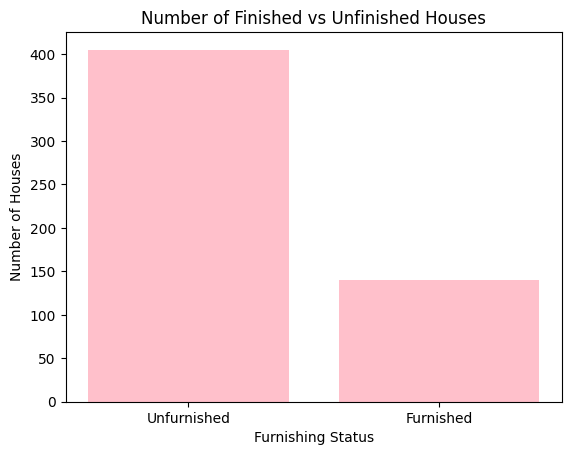

In [7]:
print("Number of furnished houses: ", len(df[df["furnishingstatus"] == 1]))
print("Number of unfirnished houses: ", len(df[df["furnishingstatus"] == 0]))

furnishing_counts = df["furnishingstatus"].value_counts()

plt.bar(furnishing_counts.index, furnishing_counts.values, tick_label=["Unfurnished", "Furnished"], color="pink")
plt.xlabel("Furnishing Status")
plt.ylabel("Number of Houses")
plt.title("Number of Finished vs Unfinished Houses")
plt.show()

Number of houses with parking cars greater then 2

Number of houses with parking of more or equal to 2 cars:  120
All remaining:  425


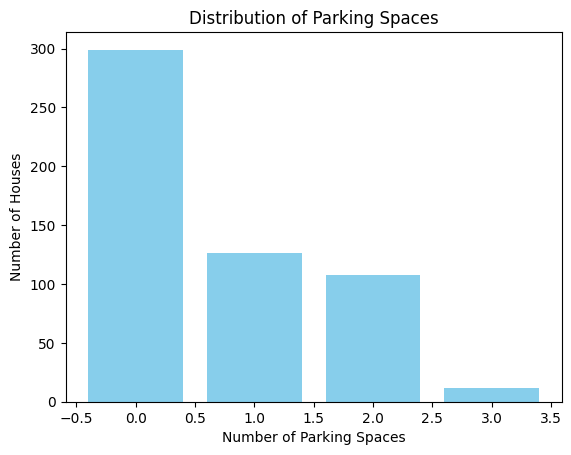

In [8]:
print("Number of houses with parking of more or equal to 2 cars: " , len(df[df["parking"] >= 2]))
print("All remaining: " , len(df[df["parking"] < 2]))

parking_counts = df["parking"].value_counts().sort_index()

plt.bar(parking_counts.index, parking_counts.values, color="skyblue")
plt.xlabel("Number of Parking Spaces")
plt.ylabel("Number of Houses")
plt.title("Distribution of Parking Spaces")
plt.show()

Air conditioning houses and non-airconditioning houses

Number of houses with airconditioning:  172
Number of houses without airconditioning:  373


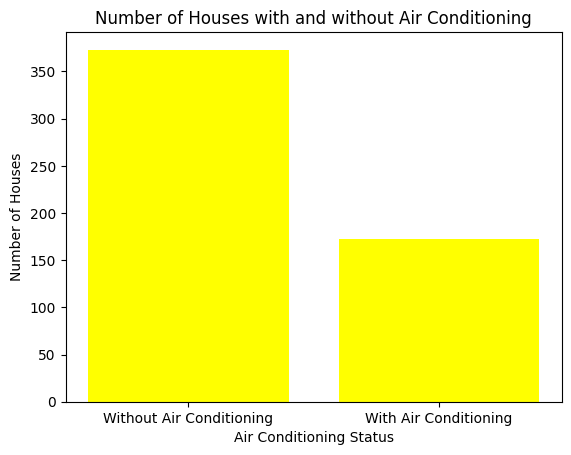

In [9]:
print("Number of houses with airconditioning: ", len(df[df["airconditioning"] == 1]))
print("Number of houses without airconditioning: ", len(df[df["airconditioning"] == 0]))

airconditioning_counts = df["airconditioning"].value_counts()

plt.bar(airconditioning_counts.index, airconditioning_counts.values, tick_label=["Without Air Conditioning", "With Air Conditioning"], color="yellow")
plt.xlabel("Air Conditioning Status")
plt.ylabel("Number of Houses")
plt.title("Number of Houses with and without Air Conditioning")
plt.show()

Number of houses with and without basement

Number of houses with basement:  191
Number of houses without basement:  354


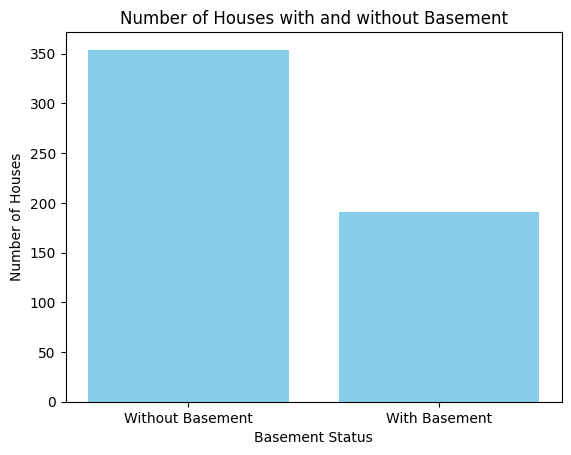

In [10]:
print("Number of houses with basement: ", len(df[df["basement"] == 1]))
print("Number of houses without basement: ", len(df[df["basement"] == 0]))

basement_counts = df["basement"].value_counts()

plt.bar(basement_counts.index, basement_counts.values, tick_label=["Without Basement", "With Basement"], color="skyblue")
plt.xlabel("Basement Status")
plt.ylabel("Number of Houses")
plt.title("Number of Houses with and without Basement")
plt.show()

Number of houses with stories morethen equal to 2

Number of houses with stories of more or equal to 2:  318
All remianing:  227


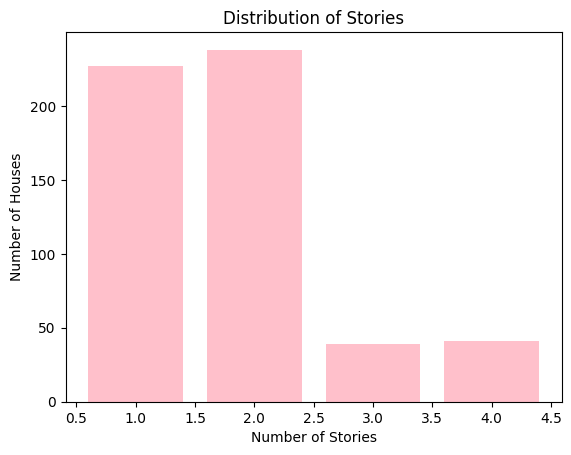

In [11]:
print("Number of houses with stories of more or equal to 2: " , len(df[df["stories"] >= 2]))
print("All remianing: " , len(df[df["stories"] < 2]))

stories_counts = df["stories"].value_counts().sort_index()

plt.bar(stories_counts.index, stories_counts.values, color="pink")
plt.xlabel("Number of Stories")
plt.ylabel("Number of Houses")
plt.title("Distribution of Stories")
plt.show()

Number of houses with attach bathrooms

Number of houses with attach bathrooms are:  15
All remaining:  530


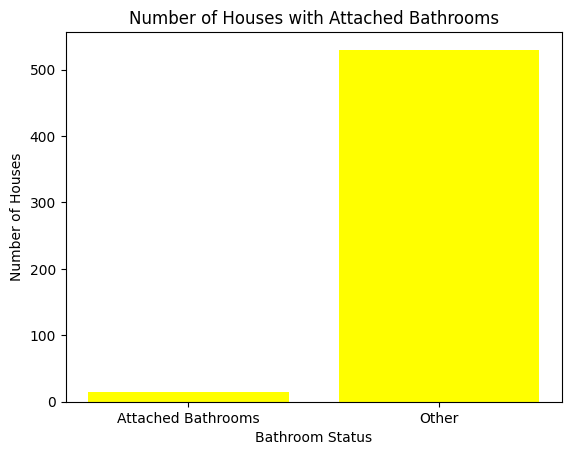

In [12]:
print("Number of houses with attach bathrooms are: ", len(df[df["bathrooms"] == df["bedrooms"]]))
print("All remaining: " , len(df[df["bathrooms"] != df["bedrooms"]]))

bathroom_bedroom_counts = pd.Series([len(df[df["bathrooms"] == df["bedrooms"]]), len(df[df["bathrooms"] != df["bedrooms"]])], index=["Attached Bathrooms", "Other"])


plt.bar(bathroom_bedroom_counts.index, bathroom_bedroom_counts.values, color="yellow")
plt.xlabel("Bathroom Status")
plt.ylabel("Number of Houses")
plt.title("Number of Houses with Attached Bathrooms")
plt.show()

# Getting X, Y splits

In [13]:
test, train = np.split(df.sample(frac=1), [int(0.7*len(df))])

/usr/local/lib/python3.12/dist-packages/numpy/_core/fromnumeric.py:57: FutureWarning: 'DataFrame.swapaxes' is deprecated and will be removed in a future version. Please use 'DataFrame.transpose' instead.
  return bound(*args, **kwds)


In [14]:
def get_xy(df):
  x = df[df.columns[:-1]].values
  y = df[df.columns[-1]].values

  return x, y

In [15]:
x_train, y_train = get_xy(train)
x_test, y_test = get_xy(test)

# Logistic regression

In [16]:
regression = LogisticRegression().fit(x_train, y_train)
regression.predict(x_test)
print("Test accuracy: ", regression.score(x_test, y_test))
print("Train accuracy: ", regression.score(x_train, y_train))
# Overy small differnece almost no overfitting

Test accuracy:  0.7611548556430446
Test accuracy:  0.7012195121951219


In [17]:
print(classification_report(y_test, regression.predict(x_test)))

              precision    recall  f1-score   support

           0       0.76      1.00      0.86       290
           1       0.00      0.00      0.00        91

    accuracy                           0.76       381
   macro avg       0.38      0.50      0.43       381
weighted avg       0.58      0.76      0.66       381



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# Testing if we have better results for Regularization

In this case there is no use of regularization

Ridge

In [18]:
regression = Ridge(alpha=1).fit(x_train, y_train)
regression.predict(x_test)
print("Test accuracy: ", regression.score(x_test, y_test))
print("Train accuracy: ", regression.score(x_train, y_train))
# Overy small differnece almost no overfitting

Test accuracy:  -0.11788734776574139
Test accuracy:  0.16271650947020333


Lasso

In [19]:
regression = Lasso(alpha=1).fit(x_train, y_train)
regression.predict(x_test)
print("Test accuracy: ", regression.score(x_test, y_test))
print("Train accuracy: ", regression.score(x_train, y_train))
# Overy small differnece almost no overfitting

Test accuracy:  0.012837039877012346
Test accuracy:  0.08138843039315424
